In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


In [2]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_tilt.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_eddies


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q22,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.123684,118.032741,47.992205,1.501133,74.597458,107,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
1,1,1463,CE,160.820027,-29.753172,257,272,905.254559,1345.866439,-0.000020,...,1.022306,108.004573,52.019741,1.386398,68.599374,107,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,0.765331,109.827647,54.305771,1.458227,78.300764,107,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,0.871468,111.650721,56.591801,1.411879,69.625773,107,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,33.976111,184.917110
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,0.945071,115.925719,57.471319,1.597888,72.613632,107,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,30.065523,181.172847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157793,3842,10646,CE,155.134295,-40.092889,223,14,711.617369,69.895295,-0.000013,...,0.903800,57.890310,10.534469,1.148690,54.275882,22,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,23.512541,69.098943
157794,3842,10647,CE,154.883954,-40.396445,221,6,699.853461,30.349325,-0.000007,...,1.216728,61.813856,10.733594,1.253634,46.817975,22,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,20.463430,69.913173
157795,3842,10648,CE,155.001742,-40.518521,223,4,713.016589,20.865525,-0.000007,...,1.267517,65.737402,10.932719,1.306102,46.695383,22,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
157796,3842,10649,CE,155.187153,-40.282064,225,10,721.413917,51.393389,-0.000010,...,1.276832,69.660948,11.131844,1.241162,47.190073,22,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN


In [3]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]


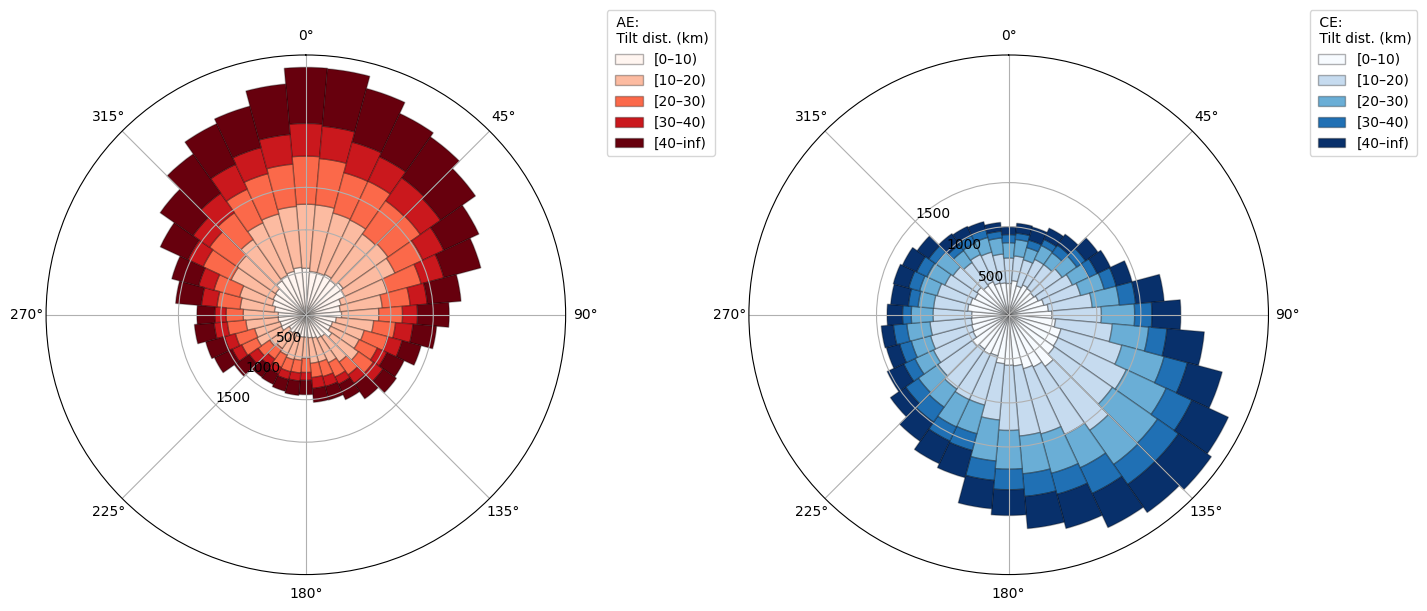

In [12]:
df_AE = df_eddies[df_eddies.Cyc == 'AE'].copy()
df_CE = df_eddies[df_eddies.Cyc == 'CE'].copy()

def choose_dir_bins_cardinal(*dfs, col='TiltDir', min_bins=8, max_bins=36, min_avg_per_sector=8):
    candidates = np.array([4, 6, 8, 9, 10, 12, 15, 16, 18, 20, 24, 30, 36, 45, 60, 72])
    candidates = candidates[(candidates >= min_bins) & (candidates <= max_bins)]
    candidates = candidates[candidates % 4 == 0]  # ensures centres can hit N/E/S/W

    Ns = []
    for df in dfs:
        x = df[col].to_numpy()
        x = x[np.isfinite(x)]
        Ns.append(x.size)
    N = min(Ns) if Ns else 0
    if N == 0 or candidates.size == 0:
        k = 16
    else:
        k0 = int(np.ceil(2 * N ** (1/3)))  # Rice rule
        k = candidates[np.argmin(np.abs(candidates - k0))]

        while k > candidates.min() and (N / k) < min_avg_per_sector:
            k = candidates[candidates < k].max()

    dir_bins = np.linspace(0.0, 360.0, k + 1)
    shift = 180.0 / k  # half-bin shift -> centres at 0, 90, 180, 270
    return dir_bins, shift

# --- bins ---
dir_bins, dir_shift = choose_dir_bins_cardinal(df_AE, df_CE, col='TiltDir', min_bins=8, max_bins=36, min_avg_per_sector=8)
# mag_bins = [0, 20, 40, 60, 80, np.inf]
mag_bins = [0, 10, 20, 30, 40, np.inf]

k = len(dir_bins) - 1
binw_deg = 360.0 / k
angles = np.deg2rad(np.arange(k) * binw_deg)   # centres: 0, binw, 2*binw, ...
width = np.deg2rad(binw_deg)

colors1 = plt.cm.Reds(np.linspace(0, 1, len(mag_bins) - 1))
colors2 = plt.cm.Blues(np.linspace(0, 1, len(mag_bins) - 1))

fig, axs = plt.subplots(
    1, 2,
    subplot_kw={'projection': 'polar'},
    figsize=(14, 6),
    constrained_layout=True
)

for a, (ax, (df, title)) in enumerate(zip(axs, [(df_AE, 'AE'), (df_CE, 'CE')])):
    directions = np.mod(df.TiltDir.to_numpy(), 360.0)
    magnitudes = df.TiltDis.to_numpy()
    mask = np.isfinite(directions) & np.isfinite(magnitudes)
    directions = directions[mask]
    magnitudes = magnitudes[mask]

    # shift so bins are centred on N/E/S/W
    directions_s = np.mod(directions + dir_shift, 360.0)

    dir_idx = np.digitize(directions_s, dir_bins, right=False) - 1
    mag_idx = np.digitize(magnitudes, mag_bins, right=False) - 1

    counts = np.zeros((len(mag_bins) - 1, k))
    for d_i, m_i in zip(dir_idx, mag_idx):
        if 0 <= d_i < counts.shape[1] and 0 <= m_i < counts.shape[0]:
            counts[m_i, d_i] += 1

    bottom = np.zeros(k)
    for i in range(counts.shape[0]):
        ax.bar(
            angles, counts[i], width,
            bottom=bottom,
            color=colors1[i] if a == 0 else colors2[i],
            edgecolor=(0, 0, 0, 0.3),
            label=f'[{mag_bins[i]:g}–{mag_bins[i+1]:g})'
        )
        bottom += counts[i]

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title=f' {title}: \n Tilt dist. (km)')

    # ax.set_rlabel_position(270)
    ax.set_rticks([500, 1000, 1500])
axs[0].set_rlabel_position(225); axs[1].set_rlabel_position(315)

plt.show()



In [5]:
df_AE = df_eddies.loc[df_eddies.Cyc == 'AE', ['TiltDir']].dropna().copy()
df_CE = df_eddies.loc[df_eddies.Cyc == 'CE', ['TiltDir']].dropna().copy()

frac_north_AE = ((df_AE.TiltDir <= 90) | (df_AE.TiltDir >= 270)).mean()
print(f'{frac_north_AE*100:.2f}% of AEs tilted northward')

frac_northeast_AE = (df_AE.TiltDir <= 90).mean()
print(f'{(frac_northeast_AE/frac_north_AE)*100:.2f}% of northward-tilting AEs had an easterly component')

frac_south_CE = ((df_CE.TiltDir >= 90) & (df_CE.TiltDir <= 270)).mean()
print(f'{frac_south_CE*100:.2f}% of CEs tilted southward')

frac_southeast_CE = ((df_CE.TiltDir >= 90) & (df_CE.TiltDir <= 180)).mean()
print(f'{(frac_southeast_CE/frac_south_CE)*100:.2f}% of southward-tilting CEs had an easterly component')


66.39% of AEs tilted northward
53.08% of northward-tilting AEs had an easterly component
63.27% of CEs tilted southward
59.38% of southward-tilting CEs had an easterly component


In [6]:
(df_eddies[df_eddies.Cyc=='AE'].dropna().TiltDis<40).mean(), (df_eddies[df_eddies.Cyc=='CE'].dropna().TiltDis<40).mean()

(np.float64(0.7973566858398501), np.float64(0.8567618294971846))

In [7]:
(df_eddies.dropna().TiltDis<=20).mean()

np.float64(0.541612982141401)

In [8]:
df_eddies.Rc.median()

np.float64(70.85483776543632)

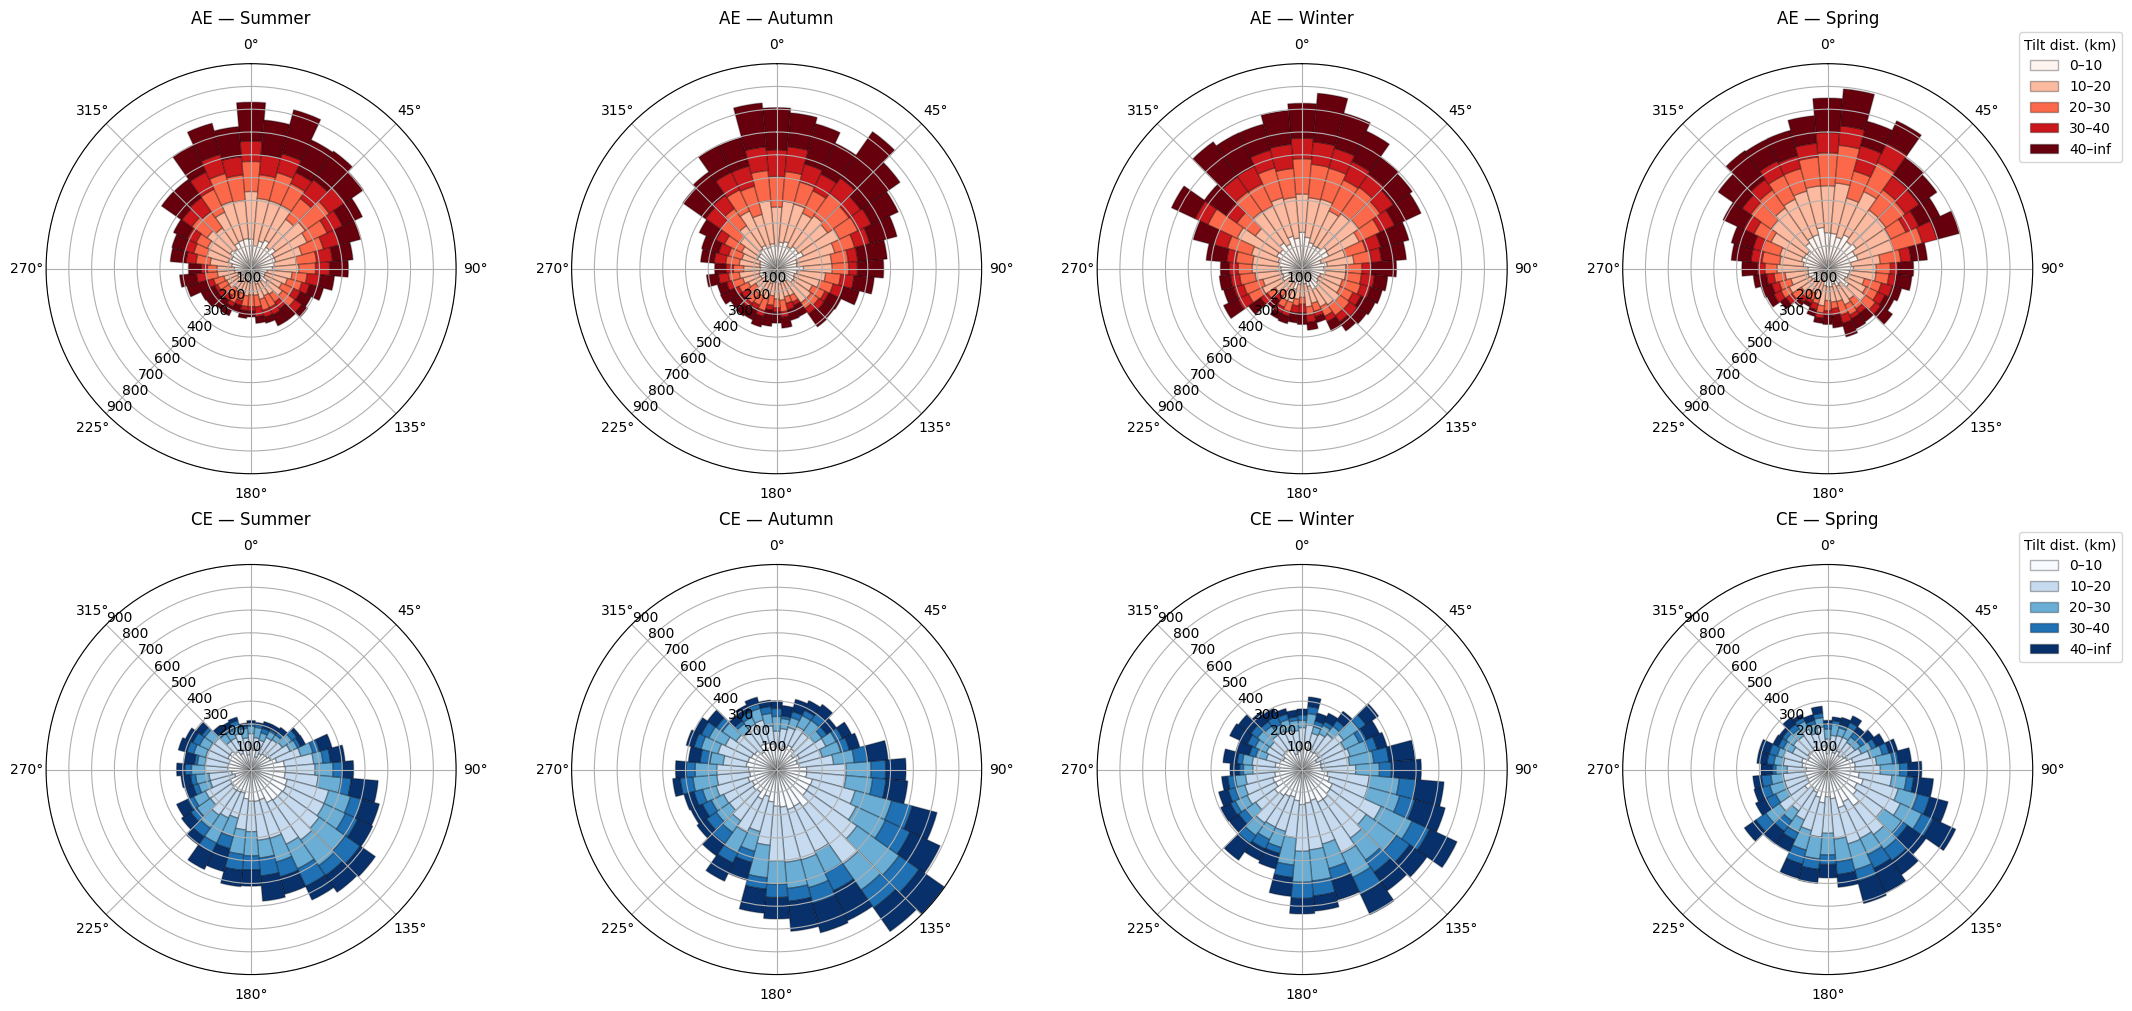

In [9]:
df_AE = df_eddies[df_eddies.Cyc == 'AE'].copy()
df_CE = df_eddies[df_eddies.Cyc == 'CE'].copy()

def choose_dir_bins_cardinal(*dfs, col='TiltDir', min_bins=8, max_bins=36, min_avg_per_sector=8):
    candidates = np.array([4, 6, 8, 9, 10, 12, 15, 16, 18, 20, 24, 30, 36, 45, 60, 72])
    candidates = candidates[(candidates >= min_bins) & (candidates <= max_bins)]
    candidates = candidates[candidates % 4 == 0]

    Ns = []
    for df in dfs:
        x = df[col].to_numpy()
        x = x[np.isfinite(x)]
        Ns.append(x.size)
    N = min(Ns) if Ns else 0

    if N == 0 or candidates.size == 0:
        k = 16
    else:
        k0 = int(np.ceil(2 * N ** (1/3)))
        k = candidates[np.argmin(np.abs(candidates - k0))]
        while k > candidates.min() and (N / k) < min_avg_per_sector:
            k = candidates[candidates < k].max()

    dir_bins = np.linspace(0.0, 360.0, k + 1)
    shift = 180.0 / k
    return dir_bins, shift

def add_season(df, time_col='Date', season_col='Season'):
    t = pd.to_datetime(df[time_col], errors='coerce')
    m = t.dt.month
    season = np.select(
        [m.isin([12, 1, 2]), m.isin([3, 4, 5]), m.isin([6, 7, 8]), m.isin([9, 10, 11])],
        ['Summer', 'Autumn', 'Winter', 'Spring'],
        default='Unknown'
    )
    df[season_col] = season
    return df

df_AE = add_season(df_AE, time_col='Date')
df_CE = add_season(df_CE, time_col='Date')
df_AE = df_AE[df_AE.Season != 'Unknown']
df_CE = df_CE[df_CE.Season != 'Unknown']

dir_bins, dir_shift = choose_dir_bins_cardinal(df_AE, df_CE, col='TiltDir', min_bins=8, max_bins=36, min_avg_per_sector=8)
mag_bins = [0, 10, 20, 30, 40, np.inf]

k = len(dir_bins) - 1
binw_deg = 360.0 / k
angles = np.deg2rad(np.arange(k) * binw_deg)
width = np.deg2rad(binw_deg)

colors_AE = plt.cm.Reds(np.linspace(0, 1, len(mag_bins) - 1))
colors_CE = plt.cm.Blues(np.linspace(0, 1, len(mag_bins) - 1))

def plot_windrose(ax, df, title, colors, rlabel_pos, rlim=None):
    directions = np.mod(df.TiltDir.to_numpy(), 360.0)
    magnitudes = df.TiltDis.to_numpy()
    mask = np.isfinite(directions) & np.isfinite(magnitudes)
    directions = directions[mask]
    magnitudes = magnitudes[mask]

    directions_s = np.mod(directions + dir_shift, 360.0)
    dir_idx = np.digitize(directions_s, dir_bins, right=False) - 1
    mag_idx = np.digitize(magnitudes, mag_bins, right=False) - 1

    counts = np.zeros((len(mag_bins) - 1, k))
    for d_i, m_i in zip(dir_idx, mag_idx):
        if 0 <= d_i < k and 0 <= m_i < (len(mag_bins) - 1):
            counts[m_i, d_i] += 1

    bottom = np.zeros(k)
    for i in range(counts.shape[0]):
        ax.bar(
            angles, counts[i], width,
            bottom=bottom,
            color=colors[i],
            edgecolor=(0, 0, 0, 0.3),
        )
        bottom += counts[i]

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_title(title, pad=10)
    ax.set_rlabel_position(rlabel_pos)
    if rlim is not None:
        ax.set_rlim(0, rlim)

seasons = ['Summer', 'Autumn', 'Winter', 'Spring']

fig, axs = plt.subplots(
    2, 4,
    subplot_kw={'projection': 'polar'},
    figsize=(21, 10),
    constrained_layout=True
)

for j, s in enumerate(seasons):
    dfa = df_AE[df_AE.Season == s]
    dfc = df_CE[df_CE.Season == s]

    plot_windrose(axs[0, j], dfa, f'AE — {s}', colors_AE, rlabel_pos=225, rlim=900)
    plot_windrose(axs[1, j], dfc, f'CE — {s}', colors_CE, rlabel_pos=315, rlim=900)

# single legend for mag bins (whole figure)
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=colors_AE[i], edgecolor=(0, 0, 0, 0.3))
           for i in range(len(mag_bins) - 1)]
labels = [f'{mag_bins[i]:g}–{mag_bins[i+1]:g}' for i in range(len(mag_bins) - 1)]
fig.legend(handles, labels, title='Tilt dist. (km)', loc='upper right', bbox_to_anchor=(1.02, 0.98))

# single legend for mag bins (whole figure)
handles = [plt.Rectangle((1, 0), 1, 1, facecolor=colors_CE[i], edgecolor=(0, 0, 0, 0.3))
           for i in range(len(mag_bins) - 1)]
labels = [f'{mag_bins[i]:g}–{mag_bins[i+1]:g}' for i in range(len(mag_bins) - 1)]
fig.legend(handles, labels, title='Tilt dist. (km)', loc='upper right', bbox_to_anchor=(1.02, 0.48))

plt.show()


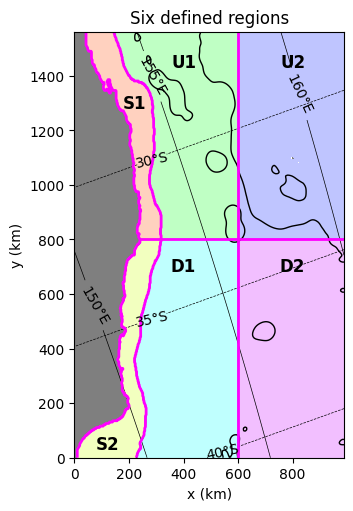

In [10]:
region_mask_grid = (h < 4e3) & (X_grid < 400) & (lon_rho < 154.85) & (mask_rho == 1)

xsplit = 600
ysplit = 800

bin_grid = np.full(X_grid.shape, np.nan)

# left region, split into two by y = 800
bin_grid[region_mask_grid & (Y_grid >= ysplit)] = 1
bin_grid[region_mask_grid & (Y_grid <  ysplit)] = 2

# outside region, left of x = 600, split by boundary of region_mask_grid
bin_grid[(~region_mask_grid) & (X_grid < xsplit) & (mask_rho == 1) & (Y_grid >= ysplit)] = 3
bin_grid[(~region_mask_grid) & (X_grid < xsplit) & (mask_rho == 1) & (Y_grid <  ysplit)] = 4

# right of x = 600, split by y = 800
bin_grid[(X_grid >= xsplit) & (mask_rho == 1) & (Y_grid >= ysplit)] = 5
bin_grid[(X_grid >= xsplit) & (mask_rho == 1) & (Y_grid <  ysplit)] = 6


fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)

ax.contourf(X_grid, Y_grid, np.where(mask_rho == 0, 1, np.nan),
            levels=[0.5, 1.5], colors=['k'], alpha=.5)

ax.contourf(X_grid, Y_grid, bin_grid,
            levels=np.arange(0.5, 7.5, 1),
            alpha=0.25, cmap='gist_rainbow')

c1 = ax.contour(X_grid, Y_grid, lat_rho, levels=levels_lat, colors='k', linewidths=.5)
ax.clabel(c1, fmt=lambda v: f"{np.abs(v):.0f}°S", inline=True, colors='k')

c2 = ax.contour(X_grid, Y_grid, lon_rho, levels=levels_lon, colors='k', linewidths=.5)
ax.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')

ax.contour(X_grid, Y_grid, h, levels=[4000], colors='k', linewidths=1)
ax.contour(X_grid, Y_grid, region_mask_grid.astype(float),
           levels=[0.5], colors='magenta', linewidths=2)

ax.axvline(xsplit, color='magenta', lw=2)
# ax.axhline(ysplit, color='k', lw=1)
ax.plot([240, X_grid.max()], [ysplit, ysplit], 'magenta', lw=2)

ax.text(220, 1300, 'S1', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(120, 50, 'S2', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(400, 1450, 'U1', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(800, 1450, 'U2', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(400, 700, 'D1', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(800, 700, 'D2', ha='center', va='center', fontsize=12, fontweight='bold')

ax.set_aspect('equal')
ax.set_xlim(X_grid.min(), X_grid.max())
ax.set_ylim(Y_grid.min(), Y_grid.max())
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.set_title('Six defined regions')

plt.show()


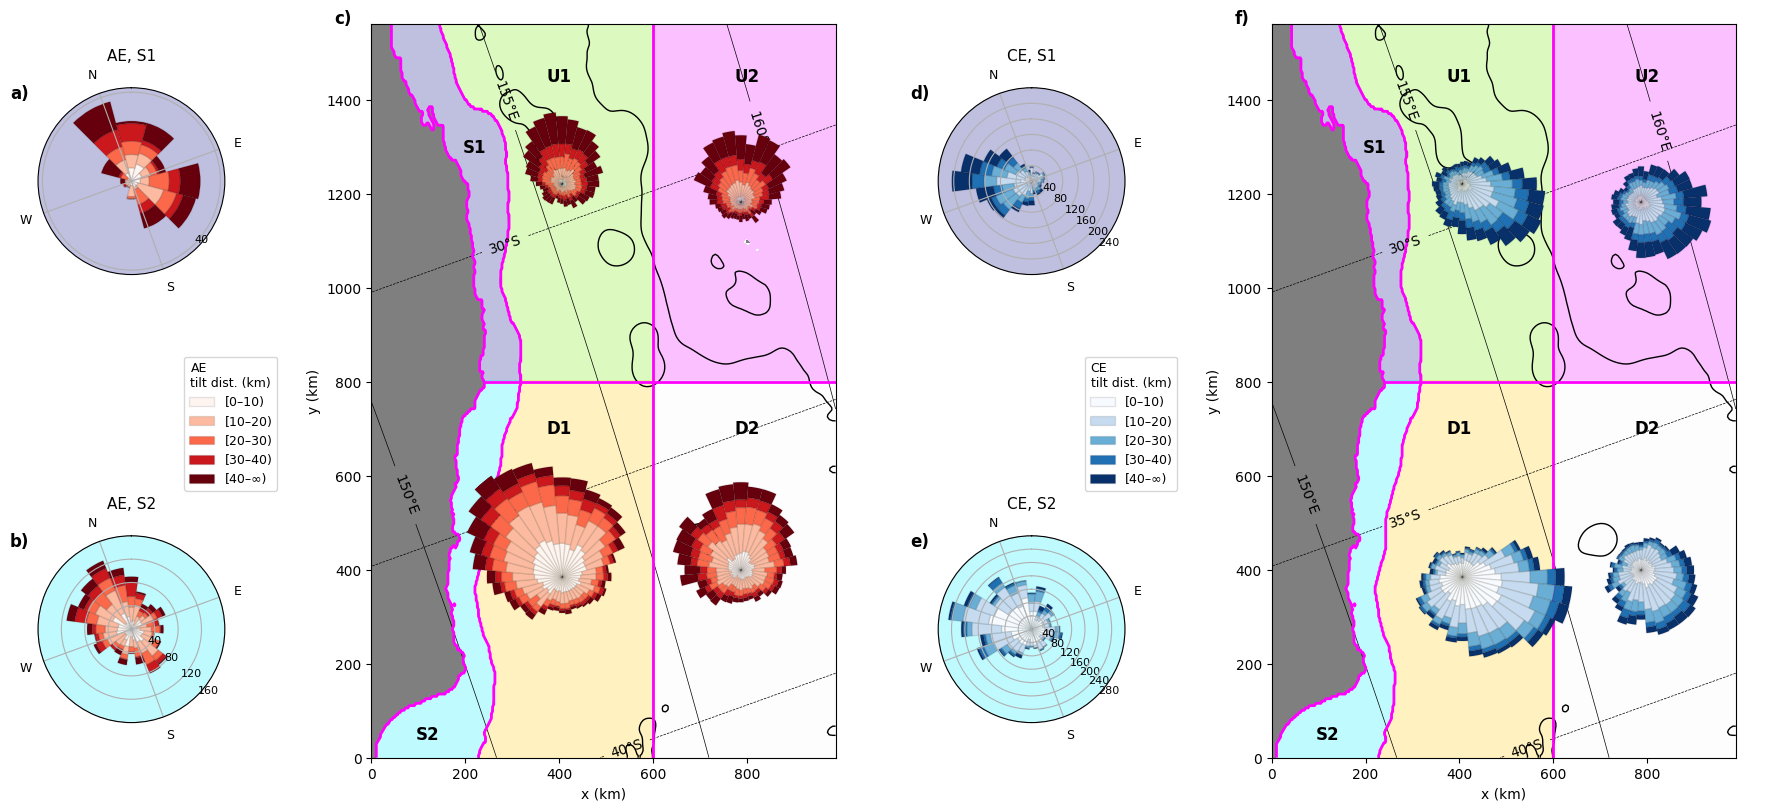

In [11]:
df_AE = df_eddies[df_eddies.Cyc == 'AE'].copy()
df_CE = df_eddies[df_eddies.Cyc == 'CE'].copy()

# ---------------- six-bin region grid ----------------
region_mask_grid = (h < 4e3) & (X_grid < 400) & (lon_rho < 154.85) & (mask_rho == 1)

xsplit = 600
ysplit = 800

bin_grid = np.full(X_grid.shape, np.nan)

bin_grid[region_mask_grid & (Y_grid >= ysplit)] = 1
bin_grid[region_mask_grid & (Y_grid <  ysplit)] = 2

bin_grid[(~region_mask_grid) & (X_grid < xsplit) & (mask_rho == 1) & (Y_grid >= ysplit)] = 3
bin_grid[(~region_mask_grid) & (X_grid < xsplit) & (mask_rho == 1) & (Y_grid <  ysplit)] = 4

bin_grid[(X_grid >= xsplit) & (mask_rho == 1) & (Y_grid >= ysplit)] = 5
bin_grid[(X_grid >= xsplit) & (mask_rho == 1) & (Y_grid <  ysplit)] = 6

# ---------------- assign eddy-days to bins ----------------
df_plot = df_eddies.copy()

bin_id = []
for row in df_plot.itertuples():
    idx = np.nanargmin((X_grid - row.xc)**2 + (Y_grid - row.yc)**2)
    bin_id.append(bin_grid.ravel()[idx])

df_plot['bin_id'] = bin_id
df_plot = df_plot.dropna(subset=['bin_id'])
df_plot['bin_id'] = df_plot['bin_id'].astype(int)

# ---------------- windrose setup ----------------
mag_bins = [0, 10, 20, 30, 40, np.inf]

colors_cmps = [
    plt.cm.Reds(np.linspace(0, 1, len(mag_bins) - 1)),
    plt.cm.Blues(np.linspace(0, 1, len(mag_bins) - 1)),
]

cell_w = (X_grid.max() - X_grid.min()) / 3
cell_h = (Y_grid.max() - Y_grid.min()) / 4

from matplotlib.colors import BoundaryNorm
cmap_bins = plt.cm.gist_ncar
levels_bins = np.arange(0.5, 7.5, 1)
norm_bins = BoundaryNorm(levels_bins, cmap_bins.N)
def get_bin_color(b, alpha=0.25):
    color = list(cmap_bins(norm_bins(b)))
    color[-1] = alpha
    return color

def choose_local_dir_bins(directions_deg, min_bins=8, max_bins=36, min_avg_per_sector=8):
    candidates = np.array([4, 8, 12, 16, 20, 24, 28, 32, 36])
    candidates = candidates[(candidates >= min_bins) & (candidates <= max_bins)]

    d = np.asarray(directions_deg, float)
    d = d[np.isfinite(d)]
    N = len(d)

    if N == 0:
        k = 8
    else:
        k0 = int(np.ceil(2 * N ** (1 / 3)))
        k = candidates[np.argmin(np.abs(candidates - k0))]

        while k > candidates.min() and (N / k) < min_avg_per_sector:
            k = candidates[candidates < k].max()

    dir_bins = np.linspace(0, 360, k + 1)
    dir_shift = 180 / k

    return dir_bins, dir_shift

def windrose_counts(directions_deg, magnitudes, *, mag_bins):
    d = np.asarray(directions_deg, float)
    m = np.asarray(magnitudes, float)

    ok = np.isfinite(d) & np.isfinite(m)
    d = d[ok]
    m = m[ok]

    if d.size == 0:
        return None, None, None, None

    dir_bins, dir_shift = choose_local_dir_bins(d)

    k = len(dir_bins) - 1
    binw_deg = 360 / k
    angles = np.deg2rad(np.arange(k) * binw_deg)
    width = np.deg2rad(binw_deg)

    d = np.mod(d + dir_shift, 360)

    di = np.digitize(d, dir_bins, right=False) - 1
    mi = np.digitize(m, mag_bins, right=False) - 1

    c = np.zeros((len(mag_bins) - 1, k), float)

    ok = (di >= 0) & (di < k) & (mi >= 0) & (mi < len(mag_bins) - 1)
    for d_i, m_i in zip(di[ok], mi[ok]):
        c[m_i, d_i] += 1

    return c, angles, width, k

def add_windrose(ax, x0, y0, data, colors, rmax, *, frac=1.6, tick_flag=False, title=''):
    c, angles, width, k = data

    if c is None:
        return None

    s = frac * min(cell_w, cell_h)

    iax = ax.inset_axes(
        [x0 - s / 2, y0 - s / 2, s, s],
        transform=ax.transData,
        projection='polar'
    )

    bottom = np.zeros(k)

    for i in range(len(mag_bins) - 1):
        hi = "∞" if np.isinf(mag_bins[i + 1]) else f"{mag_bins[i + 1]:g}"
        label = f"{mag_bins[i]:g}–{hi}"

        iax.bar(
            angles, c[i],
            width=width,
            bottom=bottom,
            color=colors[i],
            edgecolor=(0, 0, 0, 0.1),
            label=label
        )

        bottom += c[i]

    iax.set_rlim(0, rmax)
    iax.set_theta_zero_location('N')
    iax.set_theta_direction(-1)
    iax.set_xticks([])
    iax.set_yticks([])
    iax.set_frame_on(False)

    if tick_flag:
        iax.legend(
            title=title,
            loc='center left',
            bbox_to_anchor=(1.1, 0.5),
            frameon=True,
            fontsize=9,
            title_fontsize=9
        )

    return iax

def plot_standalone_windrose(ax, data, colors, b, title='', tick_flag=False, rmax=None):
    c, angles, width, k = data

    if c is None:
        ax.set_axis_off()
        return
    ax.set_facecolor(get_bin_color(b, alpha=0.25))

    bottom = np.zeros(k)

    for i in range(len(mag_bins) - 1):
        hi = "∞" if np.isinf(mag_bins[i + 1]) else f"{mag_bins[i + 1]:g}"
        label = f"[{mag_bins[i]:g}–{hi})"
        ax.bar(
            angles, c[i],
            width=width,
            bottom=bottom,
            color=colors[i],
            edgecolor=(0, 0, 0, 0.1),
            label=label
        )
        bottom += c[i]

    local_rmax = np.max(c.sum(axis=0))
    local_rmax = 1 if local_rmax == 0 else local_rmax

    ax.set_rlim(0, local_rmax + 5)
    step = 40
    top = int(np.ceil(local_rmax / step) * step)
    rticks = np.arange(step, top + step, step)
    ax.set_rticks(rticks)
    ax.set_yticklabels([f'{t:g}' for t in rticks], fontsize=8)
    ax.set_rlabel_position(135)

    if rmax is not None:
        ax.set_rlim(0, rmax)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    cardinal_angles = np.deg2rad([340, 70, 160, 250])
    
    ax.set_xticks(cardinal_angles)
    ax.set_xticklabels(['N', 'E', 'S', 'W'], fontsize=9)
    ax.set_title(title, fontsize=11)

    if tick_flag:
        ax.legend(
            title=f'{title[:2]}\ntilt dist. (km)',
            loc='center left',
            bbox_to_anchor=(.75, 1.6),
            frameon=True,
            fontsize=9,
            title_fontsize=9
        )

# ---------------- bin centres ----------------
bin_centers = {}

for b in range(1, 7):
    yy, xx = np.where(bin_grid == b)
    bin_centers[b] = (
        np.nanmean(X_grid[yy, xx]),
        np.nanmean(Y_grid[yy, xx])
    )

# ---------------- counts ----------------
counts = {}

for cyc in ['AE', 'CE']:
    for b in range(1, 7):
        sub = df_plot[(df_plot.Cyc == cyc) & (df_plot.bin_id == b)]

        d = (sub.TiltDir.to_numpy() - 20.0) % 360.0
        m = sub.TiltDis.to_numpy()

        counts[(cyc, b)] = windrose_counts(d, m, mag_bins=mag_bins)

# map windroses share scale for regions 3–6 only
rmax_map = 0

for cyc in ['AE', 'CE']:
    for b in [3, 4, 5, 6]:
        c = counts[(cyc, b)][0]
        if c is not None:
            rmax_map = max(rmax_map, np.max(c.sum(axis=0)))

rmax_map = 1 if rmax_map == 0 else rmax_map

# ---------------- plotting ----------------
fig = plt.figure(figsize=(18, 8), constrained_layout=True)
gs = fig.add_gridspec(1, 4, width_ratios=[1.2, 2.6, 1.2, 2.6])

gs_AE_small = gs[0, 0].subgridspec(2, 1)
gs_CE_small = gs[0, 2].subgridspec(2, 1)

small_axes = {
    ('AE', 1): fig.add_subplot(gs_AE_small[0, 0], projection='polar'),
    ('AE', 2): fig.add_subplot(gs_AE_small[1, 0], projection='polar'),
    ('CE', 1): fig.add_subplot(gs_CE_small[0, 0], projection='polar'),
    ('CE', 2): fig.add_subplot(gs_CE_small[1, 0], projection='polar'),
}

axs = {
    'AE': fig.add_subplot(gs[0, 1]),
    'CE': fig.add_subplot(gs[0, 3])
}

for p, cyc in enumerate(['AE', 'CE']):
    for b in [1, 2]:
        plot_standalone_windrose(
            small_axes[(cyc, b)],
            counts[(cyc, b)],
            colors_cmps[p],
            b,
            title=f'{cyc}, S{b}',
            tick_flag = True if b==2 else False,
            rmax= None #70 if p==0 else 90
        )

for p, cyc in enumerate(['AE', 'CE']):
    ax = axs[cyc]

    ax.contourf(X_grid, Y_grid, np.where(mask_rho == 0, 1, np.nan),
                levels=[0.5, 1.5], colors=['k'], alpha=.5)

    # ax.contourf(X_grid, Y_grid, bin_grid,
    #             levels=np.arange(0.5, 7.5, 1),
    #             alpha=0.25, cmap='hsv')

    ax.contourf(
        X_grid, Y_grid, bin_grid,
        levels=levels_bins,
        cmap=cmap_bins,
        norm=norm_bins,
        alpha=0.25
    )

    c1 = ax.contour(X_grid, Y_grid, lat_rho, levels=levels_lat, colors='k', linewidths=.5)
    ax.clabel(c1, fmt=lambda v: f"{np.abs(v):.0f}°S", inline=True, colors='k')

    c2 = ax.contour(X_grid, Y_grid, lon_rho, levels=levels_lon, colors='k', linewidths=.5)
    ax.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')

    ax.contour(X_grid, Y_grid, h, levels=[4000], colors='k', linewidths=1)
    ax.contour(X_grid, Y_grid, region_mask_grid.astype(float),
               levels=[0.5], colors='magenta', linewidths=2)

    # ax.axvline(xsplit, color='k', lw=1)
    # ax.axhline(ysplit, color='k', lw=1)
    ax.axvline(xsplit, color='magenta', lw=2)
    ax.plot([240, X_grid.max()], [ysplit, ysplit], 'magenta', lw=2)

    for b in [3, 4, 5, 6]:
        x0, y0 = bin_centers[b]

        add_windrose(
            ax, x0, y0,
            counts[(cyc, b)],
            colors_cmps[p],
            rmax_map,
            frac=1.6,
            # tick_flag=(b == 6),
            title=f'{cyc}-days:\nTilt dist. (km)'
        )

    ax.text(220, 1300, 'S1', ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(120, 50, 'S2', ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(400, 1450, 'U1', ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(800, 1450, 'U2', ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(400, 700, 'D1', ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(800, 700, 'D2', ha='center', va='center', fontsize=12, fontweight='bold')

    ax.set_aspect('equal')
    ax.set_xlim(X_grid.min(), X_grid.max())
    ax.set_ylim(Y_grid.min(), Y_grid.max())
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')
    # ax.set_title(f'{cyc}-days')

axs['AE'].text(-0.08, 1.02, 'c)', transform=axs['AE'].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs['CE'].text(-0.08, 1.02, 'f)', transform=axs['CE'].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

small_axes[('AE', 1)].text(-0.15, 1.02, 'a)', transform=small_axes[('AE', 1)].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
small_axes[('AE', 2)].text(-0.15, 1.02, 'b)', transform=small_axes[('AE', 2)].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

small_axes[('CE', 1)].text(-0.15, 1.02, 'd)', transform=small_axes[('CE', 1)].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
small_axes[('CE', 2)].text(-0.15, 1.02, 'e)', transform=small_axes[('CE', 2)].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

plt.show()

